# 05 Exposure Scoring

## Goal

This notebook creates a simple preliminary exposure score for operational UK renewable energy assets.

The previous notebook created first-pass geospatial exposure features, including distance to a boundary proxy and proximity flags.

This notebook combines:

1. a proximity score,
2. an installed-capacity score,
3. a final preliminary exposure score,
4. Low / Medium / High screening categories.

This is not a production catastrophe model. The score is a transparent screening tool used to rank assets for further review.

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

exposure_path = DATA_PROCESSED / "operational_energy_assets_exposure_features.geojson"

assets = gpd.read_file(exposure_path)

print("Rows:", len(assets))
print("CRS:", assets.crs)

assets.head()

ModuleNotFoundError: No module named 'geopandas'

## What is exposure scoring?

Exposure scoring converts several risk-relevant features into a simple ranking system.

In this project, the score is not estimating financial loss, probability of failure or insured damage. Instead, it answers a simpler screening question:

> Which assets might deserve closer review first?

The score combines two ideas:

1. **Proximity** — assets closer to the boundary proxy receive a higher exposure flag.
2. **Scale** — assets with higher installed capacity receive a higher scale flag.

This creates a transparent preliminary score that can be explained, challenged and improved later.

In [82]:
assets[[
    "Site Name",
    "Technology Type",
    "Installed Capacity (MWelec)",
    "distance_to_boundary_m",
    "within_5km_boundary_proxy",
    "within_10km_boundary_proxy"
]].head()

,Site Name,Technology Type,Installed Capacity (MWelec),distance_to_boundary_m,within_5km_boundary_proxy,within_10km_boundary_proxy
0,Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,191191.372956,False,False
1,Thetford Biomass Power Station,Biomass (dedicated),38.5,90187.542957,False,False
2,Chilton Energy Plant,Biomass (dedicated),18.0,184875.461233,False,False
3,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,29462.766557,False,False
4,Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,99471.331514,False,False


## Proximity score

The proximity score is based on distance to the boundary proxy.

The logic is:

| Condition | Score | Interpretation |
|---|---:|---|
| within 5 km | 2 | higher proximity flag |
| within 10 km | 1 | moderate proximity flag |
| outside 10 km | 0 | lower proximity flag |

This is a simple screening rule. It should not be interpreted as a true flood, coastal or heat hazard score.

In [83]:
def assign_proximity_score(distance_m):
    if distance_m <= 5_000:
        return 2
    elif distance_m <= 10_000:
        return 1
    else:
        return 0

assets["proximity_score"] = assets["distance_to_boundary_m"].apply(assign_proximity_score)

assets["proximity_score"].value_counts().sort_index()

proximity_score
0    3013
1      21
2      24
Name: count, dtype: int64

## Installed-capacity score

Installed capacity is used as a simple proxy for asset scale.

A larger generation asset may matter more for infrastructure, portfolio or system-risk analysis than a very small asset.

However, installed capacity is not the same as replacement cost, insured value, revenue exposure or criticality. It is only a first-pass scale proxy.

The capacity score divides assets into three groups using terciles:

| Capacity group | Score |
|---|---:|
| lower third | 0 |
| middle third | 1 |
| upper third | 2 |

In [84]:
capacity_col = "Installed Capacity (MWelec)"

assets[capacity_col] = pd.to_numeric(assets[capacity_col], errors="coerce")

assets[capacity_col].describe()

count    3013.00000
mean       18.20843
std        72.83629
min         0.10000
25%         2.20000
50%         5.00000
75%        12.00000
max      1728.00000
Name: Installed Capacity (MWelec), dtype: float64

In [85]:
assets["capacity_score"] = pd.qcut(
    assets[capacity_col],
    q=3,
    labels=[0, 1, 2],
    duplicates="drop"
).astype("float")

assets["capacity_score"] = assets["capacity_score"].fillna(0).astype(int)

assets["capacity_score"].value_counts().sort_index()

capacity_score
0    1061
1     993
2    1004
Name: count, dtype: int64

## Preliminary exposure score

The final score combines proximity and capacity:

\[
\text{preliminary exposure score} = \text{proximity score} + \text{capacity score}
\]

The maximum score is 4 and the minimum score is 0.

This score is used only for ranking and screening. It is not a probability, loss estimate or engineering risk measure.

In [86]:
assets["preliminary_exposure_score"] = (
    assets["proximity_score"] + assets["capacity_score"]
)

assets["preliminary_exposure_score"].value_counts().sort_index()

preliminary_exposure_score
0    1048
1     983
2    1002
3      17
4       8
Name: count, dtype: int64

## Screening categories

To make the score easier to communicate, I convert the numeric score into Low, Medium and High screening categories.

| Score | Category |
|---:|---|
| 0–1 | Low |
| 2–3 | Medium |
| 4 | High |

These categories are communication labels. They do not represent validated risk bands.

In [87]:
def assign_screening_category(score):
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

assets["screening_category"] = assets["preliminary_exposure_score"].apply(assign_screening_category)

assets["screening_category"].value_counts()

screening_category
Low       2031
Medium    1019
High         8
Name: count, dtype: int64

In [88]:
assets[[
    "Site Name",
    "Technology Type",
    "Region",
    "Installed Capacity (MWelec)",
    "distance_to_boundary_m",
    "proximity_score",
    "capacity_score",
    "preliminary_exposure_score",
    "screening_category"
]].sort_values(
    "preliminary_exposure_score",
    ascending=False
).head(20)

,Site Name,Technology Type,Region,Installed Capacity (MWelec),distance_to_boundary_m,proximity_score,capacity_score,preliminary_exposure_score,screening_category
1354,Rampion Offshore Wind Farm (Hastings Zone),Wind Offshore,Offshore,400.0,0.000000,2,2,4,High
1342,Hornsea 2 - Optimus and Breesea,Wind Offshore,Offshore,1320.0,3896.293647,2,2,4,High
1357,East Anglia 1 (EA 1),Wind Offshore,Offshore,714.0,0.000000,2,2,4,High
1842,Pentland Road Wind Farm,Wind Onshore,Scotland,13.8,4353.640811,2,2,4,High
1359,Galloper Wind Farm,Wind Offshore,Offshore,353.0,0.000000,2,2,4,High
1464,Goonhilly Downs Wind Farm Repower,Wind Onshore,South West,12.0,442.458716,2,2,4,High
1340,Thanet,Wind Offshore,Offshore,300.0,0.000000,2,2,4,High
2087,Callagheen,Wind Onshore,Northern Ireland,22.8,0.000000,2,2,4,High
1100,Tilmanstone Colliery,Solar Photovoltaics,South East,10.0,6819.019163,1,2,3,Medium
1937,Point Wind / Beinn Ghrideag Farm,Wind Onshore,Scotland,9.0,8064.887187,1,2,3,Medium


## Regional exposure summary

After scoring individual assets, I summarise results by region.

This creates a portfolio-style view showing where higher-scored assets are concentrated.

The regional view is useful because risk is often managed at several levels:

- individual asset level,
- regional level,
- portfolio level.

In [89]:
regional_scoring_summary = (
    assets
    .groupby("Region")
    .agg(
        asset_count=("Ref ID", "count"),
        total_capacity_mw=("Installed Capacity (MWelec)", "sum"),
        mean_exposure_score=("preliminary_exposure_score", "mean"),
        high_screening_count=("screening_category", lambda x: (x == "High").sum()),
        medium_screening_count=("screening_category", lambda x: (x == "Medium").sum()),
        low_screening_count=("screening_category", lambda x: (x == "Low").sum())
    )
    .reset_index()
    .sort_values("high_screening_count", ascending=False)
)

regional_scoring_summary

,Region,asset_count,total_capacity_mw,mean_exposure_score,high_screening_count,medium_screening_count,low_screening_count
6,Offshore,53,14713.50,2.056604,5,43,5
5,Northern Ireland,118,1453.50,1.372881,1,62,55
7,Scotland,565,12382.83,1.097345,1,254,310
9,South West,529,3907.90,0.922495,1,119,409
0,East Midlands,268,2010.06,0.914179,0,73,195
1,Eastern,326,3378.04,1.021472,0,120,206
2,London,35,388.62,0.657143,0,8,27
3,North East,103,1319.61,0.912621,0,28,75
4,North West,194,1572.56,0.711340,0,38,156
8,South East,312,3468.95,1.009615,0,100,212


In [90]:
regional_scoring_summary.to_csv(
    TABLES / "regional_exposure_scoring_summary.csv",
    index=False
)

print("Saved regional scoring summary to:")
print(TABLES / "regional_exposure_scoring_summary.csv")

Saved regional scoring summary to:
/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/tables/regional_exposure_scoring_summary.csv


## Visualising the screening categories

The chart below shows how many assets fall into each screening category.

This helps communicate whether the score is classifying most assets as Low, Medium or High.

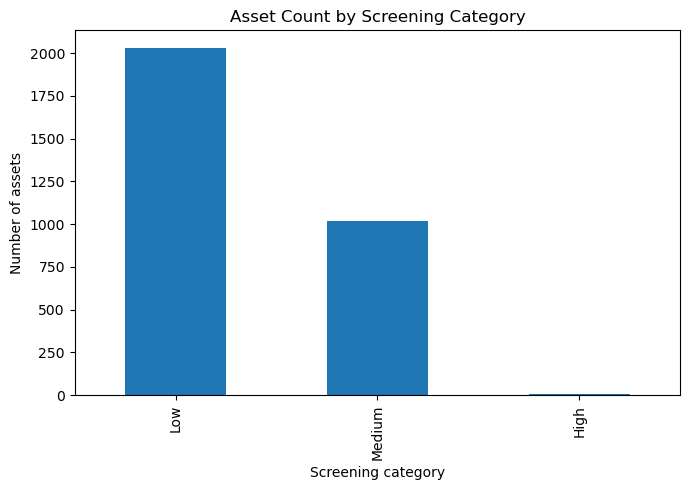

Saved figure to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/figures/screening_category_counts.png


In [91]:
category_counts = (
    assets["screening_category"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

fig, ax = plt.subplots(figsize=(7, 5))

category_counts.plot(kind="bar", ax=ax)

ax.set_title("Asset Count by Screening Category")
ax.set_xlabel("Screening category")
ax.set_ylabel("Number of assets")

plt.tight_layout()

figure_path = FIGURES / "screening_category_counts.png"
plt.savefig(figure_path, dpi=200)

plt.show()

print("Saved figure to:", figure_path)

## Saving the scored asset layer

The scored asset layer is saved for the final results and interpretation notebook.

This output contains the original asset information, geospatial exposure features, scores and screening categories.

In [92]:
scored_geojson_path = DATA_PROCESSED / "operational_energy_assets_scored.geojson"
scored_csv_path = DATA_PROCESSED / "operational_energy_assets_scored.csv"

assets.to_file(scored_geojson_path, driver="GeoJSON")
assets.drop(columns="geometry").to_csv(scored_csv_path, index=False)

print("Saved scored GeoJSON to:", scored_geojson_path)
print("Saved scored CSV to:", scored_csv_path)

Saved scored GeoJSON to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed/operational_energy_assets_scored.geojson
Saved scored CSV to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed/operational_energy_assets_scored.csv


In [93]:
check = gpd.read_file(scored_geojson_path)

print("Rows:", len(check))
print("CRS:", check.crs)
print("Columns:", len(check.columns))

check[[
    "Site Name",
    "Region",
    "preliminary_exposure_score",
    "screening_category"
]].head()

Rows: 3058
CRS: EPSG:27700
Columns: 26


,Site Name,Region,preliminary_exposure_score,screening_category
0,Ferrybridge Multifuel 2 (FM2),Yorkshire and Humber,2,Medium
1,Thetford Biomass Power Station,Eastern,2,Medium
2,Chilton Energy Plant,North East,2,Medium
3,Double H Nurseries Biomass Plant,South East,0,Low
4,Newry Biomass Phase 1 (Gasification),Northern Ireland,0,Low
